# Smart Food Image Generator - Assignment

[View on Google Colab](https://colab.research.google.com/drive/1vuLUmTAZLN5jjLOGw751a9QMY5Dei2D0?usp=sharing)

Week 8: Multimodal AI for Food Delivery Business

OBJECTIVE: Build an AI system that can generate professional food images 
and analyze them for safety using Stable Diffusion and BLIP models.

LEARNING GOALS:
- Use Stable Diffusion for text-to-image generation
- Use BLIP VQA for food analysis and safety detection
- Combine multiple AI models for practical food delivery applications
- Build a complete food generation and analysis pipeline

### Import the necessary libraries

In [4]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline
from transformers import BlipProcessor, BlipForQuestionAnswering

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [5]:
def setup_device():
    """
    Setup device for optimal performance
    
    SOLUTION: Check for available hardware and return appropriate device and data type.
    """
    if torch.cuda.is_available():
        return "cuda", torch.float16
    elif torch.backends.mps.is_available():
        return "mps", torch.float32
    else:
        return "cpu", torch.float32

# TEST: Setup device
print("🔧 TESTING: Setting up device...")
device, dtype = setup_device()
print(f"Using device: {device}")
print()

🔧 TESTING: Setting up device...
Using device: mps



---

### Load Models

In [15]:
def load_models(device, dtype):
    """
    Load all required models for food generation and analysis
    
    TODO: Load Stable Diffusion and BLIP models
    HINT: Use the model loading patterns from Week8 notebooks
    HINT: Use 'global' keyword to modify global variables
    
    MODELS TO LOAD:
    - Stable Diffusion: "runwayml/stable-diffusion-v1-5"
    - BLIP VQA: "Salesforce/blip-vqa-base"
    
    Args:
        device: Device to load models on
        dtype: Data type for models
        
    Returns:
        tuple: (text2img_pipeline, blip_model, blip_processor)
    """
    global text2img_pipe, blip_model, blip_processor
    
    print("📦 Loading models...")
    
    # TODO: Load Stable Diffusion pipeline
    text2img_pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False
    )
    text2img_pipe = text2img_pipe.to(device)

    # TODO: Load BLIP VQA model and processor
    blip_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")
    blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
    blip_model.eval()
    
    # DUMMY IMPLEMENTATION (Remove this when implementing)
    # print("⚠️ DUMMY: Models not loaded yet - implement the TODO sections above")
    
    print("✅ All models loaded successfully!")
    return text2img_pipe, blip_model, blip_processor

# TEST: Load models
print("📦 TESTING: Loading models...")
text2img_pipe, blip_model, blip_processor = load_models(device, dtype)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


📦 TESTING: Loading models...
📦 Loading models...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

✅ All models loaded successfully!


---

### Generate Food Image

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', photorealistic , food magazine cover quality']


🍽️ TESTING: Generating food image...
🍽️ Generating: Chole Bhature


  0%|          | 0/20 [00:00<?, ?it/s]

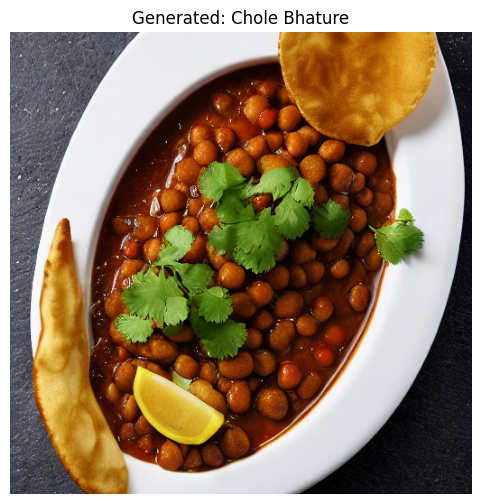

In [19]:
def generate_food_image(food_description, seed=42):
    """
    Generate professional food image from text description
    
    TODO: Implement food image generation using Stable Diffusion
    HINT: Enhance the prompt with food photography terms
    HINT: Use negative prompts to avoid unappetizing results
    HINT: Set seed for reproducible results
    
    Args:
        food_description (str): Description of food to generate
        seed (int): Random seed for reproducibility
        
    Returns:
        PIL.Image: Generated food image
        
    EXAMPLE INPUT: "butter chicken with rice and naan"
    EXAMPLE OUTPUT: PIL Image of appetizing butter chicken dish
    """
    print(f"🍽️ Generating: {food_description}")
    
    # TODO: Enhance prompt for better food photography
    prompt = f"A stunning photograph of {food_description}, professional food photography, award-winning culinary presentation, michelin star restaurant quality, perfectly plated, studio lighting, macro lens, shallow depth of field, vibrant colors, fresh ingredients, steam rising, glistening textures, artistic plating, fine dining presentation, commercial food styling, high resolution, ultra-detailed, mouth-watering, appetizing, photorealistic, food magazine cover quality"
    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    
    # TODO: Generate image using Stable Diffusion
    with torch.no_grad():
        result = text2img_pipe(
            prompt=prompt,
            negative_prompt="abstract, non-food, non-restaurant, non-food photography, non-realistic, blurry, low quality, unappetizing, burnt, raw, moldy, disgusting, bad lighting, overexposed, underexposed, poor composition, messy presentation, uncooked, spoiled, dirty, greasy, unpleasant",
            num_inference_steps=20,
            guidance_scale=7.5
        )
    
    # TODO: Return the generated image
    return result.images[0]
    

# TEST: Generate food image
print("🍽️ TESTING: Generating food image...")
test_food = "Chole Bhature"
food_image = generate_food_image(test_food)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(food_image)
plt.title(f"Generated: {test_food}")
plt.axis('off')
plt.show()
print()

---

### Question Answering about Food

In [20]:
def ask_about_food(image, question):
    """
    Ask questions about food using BLIP VQA
    
    TODO: Implement visual question answering using BLIP
    HINT: Process image and question, then generate answer
    HINT: Use the global blip_model and blip_processor
    
    Args:
        image (PIL.Image): Food image to analyze
        question (str): Question to ask about the food
        
    Returns:
        str: Answer to the question
        
    EXAMPLE INPUT: 
        image = <PIL Image of curry>
        question = "Does this contain dairy?"
        
    EXAMPLE OUTPUT: "yes"
    """
    
    # TODO: Process image and question using BLIP
    inputs = blip_processor(image, question, return_tensors="pt")
    
    # TODO: Generate answer
    with torch.no_grad():
        out = blip_model.generate(
            **inputs,
            num_beams=5,
            early_stopping=True
        )
    
    # TODO: Decode and return answer
    answer = blip_processor.decode(out[0], skip_special_tokens=True)
    return answer.strip()
    

# TEST: Ask questions about food
print("❓ TESTING: Asking questions about food...")
questions = [
    "What type of food is this?",
    "Does this contain dairy?",
    "Is this food spicy?"
]

for question in questions:
    answer = ask_about_food(food_image, question)
    print(f"Q: {question}")
    print(f"A: {answer}")
    print()


❓ TESTING: Asking questions about food...
Q: What type of food is this?
A: beans

Q: Does this contain dairy?
A: no

Q: Is this food spicy?
A: yes



---

### Analyze Food Safety

In [21]:
def analyze_food_safety(food_image):
    """
    Analyze food for ingredients and allergens
    
    TODO: Implement comprehensive food safety analysis
    HINT: Ask specific questions about allergens and dietary info
    HINT: Check for common allergens: dairy, nuts, eggs, gluten
    
    Args:
        food_image (PIL.Image): Food image to analyze
        
    Returns:
        dict: Analysis results with description, allergens, and dietary info
        
    EXAMPLE OUTPUT: {
        "description": "butter chicken with rice",
        "allergens": ["dairy", "gluten"],
        "vegetarian": "no",
        "spicy": "yes"
    }
    """
    print("🔬 Analyzing food safety...")
    
    # Get basic info
    description = ask_about_food(food_image, "What type of food is this?")
    
    # Check for common allergens
    allergen_questions = [
        "Does this contain dairy or milk?",
        "Does this contain gluten?",
    ]
    
    allergens = []
    for question in allergen_questions:
        answer = ask_about_food(food_image, question)
        if "yes" in answer.lower():
            allergen = question.split("contain ")[-1].split("?")[0]
            allergens.append(allergen)
    
    # TODO: Get dietary information
    vegetarian = ask_about_food(food_image, "Is this food vegetarian?")
    spicy = ask_about_food(food_image, "Is this food spicy?")
    
    # TODO: Compile analysis results
    analysis = {
        "description": description,
        "allergens": allergens,
        "vegetarian": vegetarian,
        "spicy": spicy
    }
    
    print("✅ Food analysis complete!")
    return analysis

# TEST: Analyze food safety
print("🔬 TESTING: Food safety analysis...")
analysis = analyze_food_safety(food_image)

print("Analysis Results:")
print(f"Description: {analysis['description']}")
print(f"Allergens: {', '.join(analysis['allergens']) if analysis['allergens'] else 'None detected'}")
print(f"Vegetarian: {analysis['vegetarian']}")
print(f"Spicy: {analysis['spicy']}")

🔬 TESTING: Food safety analysis...
🔬 Analyzing food safety...
✅ Food analysis complete!
Analysis Results:
Description: beans
Allergens: None detected
Vegetarian: yes
Spicy: yes


---

### Generate and Analyze Food

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['photorealistic , food magazine cover quality']


🚀 TESTING: Complete pipeline...

--- Testing: chocolate chip cookies ---
🚀 Complete pipeline for: chocolate chip cookies
🍽️ Generating: chocolate chip cookies


  0%|          | 0/20 [00:00<?, ?it/s]

🔬 Analyzing food safety...
✅ Food analysis complete!


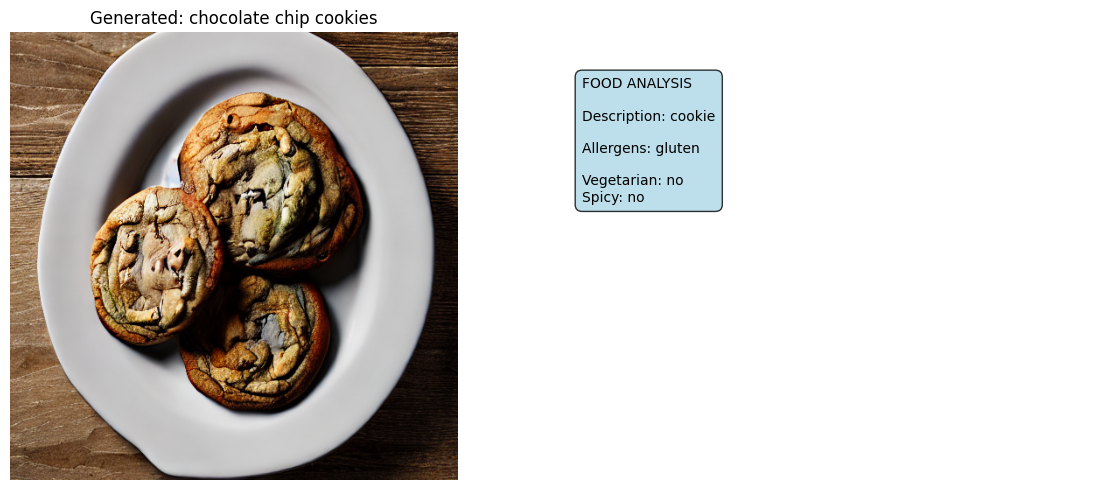

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', photorealistic , food magazine cover quality']




--- Testing: grilled salmon with vegetables ---
🚀 Complete pipeline for: grilled salmon with vegetables
🍽️ Generating: grilled salmon with vegetables


  0%|          | 0/20 [00:00<?, ?it/s]

🔬 Analyzing food safety...
✅ Food analysis complete!


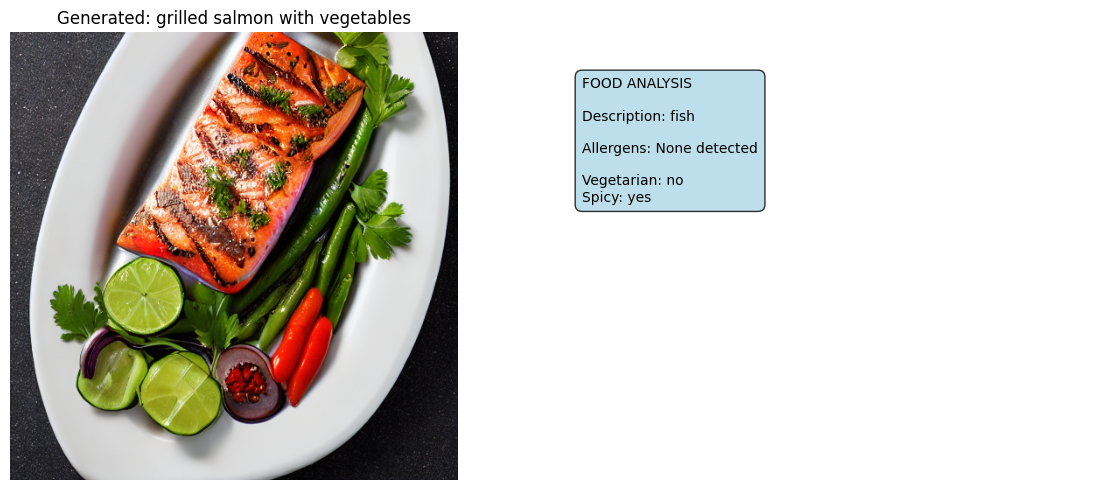

In [22]:
def generate_and_analyze_food(food_description):
    """
    Complete pipeline: generate food image and analyze it
    
    TODO: Implement the complete food generation and analysis pipeline
    HINT: Combine image generation with safety analysis
    HINT: Display results in a side-by-side format
    
    Args:
        food_description (str): Description of food to generate and analyze
        
    Returns:
        tuple: (generated_image, analysis_results)
        
    PIPELINE STEPS:
    1. Generate food image using generate_food_image()
    2. Analyze the food using analyze_food_safety()
    3. Display results with image and analysis side-by-side
    4. Return both image and analysis
    """
    print(f"🚀 Complete pipeline for: {food_description}")
    
    # TODO: Step 1 - Generate food image
    food_image = generate_food_image(food_description)
    
    # TODO: Step 2 - Analyze the food
    analysis = analyze_food_safety(food_image)
    
    # TODO: Step 3 - Display results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # # Show image
    ax1.imshow(food_image)
    ax1.set_title(f"Generated: {food_description}")
    ax1.axis('off')
    
    # # Show analysis
    ax2.axis('off')
    analysis_text = f"FOOD ANALYSIS\n\n"
    analysis_text += f"Description: {analysis['description']}\n\n"
    analysis_text += f"Allergens: {', '.join(analysis['allergens']) if analysis['allergens'] else 'None detected'}\n\n"
    analysis_text += f"Vegetarian: {analysis['vegetarian']}\n"
    analysis_text += f"Spicy: {analysis['spicy']}"
    
    ax2.text(0.1, 0.9, analysis_text, transform=ax2.transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # TODO: Step 4 - Return results
    return food_image, analysis
    

# TEST: Complete pipeline
print("🚀 TESTING: Complete pipeline...")
test_foods = [
    "chocolate chip cookies",
    "grilled salmon with vegetables"
]

for food in test_foods:
    print(f"\n--- Testing: {food} ---")
    img, result = generate_and_analyze_food(food)
    print()

---